## IPO Underpricing vs Overpricing Classification Using Support Vector Machine (SVM)

The objective of this project is to classify an IPO as Underpriced or Overpriced based on issue-stage information, using SVM.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


## Load dataset

In [2]:
df = pd.read_excel("Initial Public Offering.xlsx")
df.head()


,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
0,2026-05-14,Bagmane Prime Offi...,3405.00,17.09,15.79,0.00,16.50,100,103.4,3.40,103.92,103.97,3.92
1,2026-05-08,Onemi Technology S...,925.92,24.87,6.57,2.03,9.50,171,191.0,11.70,231.70,231.74,35.50
2,2026-04-29,Citius Transnet In...,1105.00,8.54,11.77,0.00,10.01,100,104.5,4.50,105.87,106.04,5.87
3,2026-04-17,Om Power Transmiss...,150.06,3.65,7.06,1.54,3.33,175,181.1,3.49,190.80,190.74,9.03
4,2026-04-02,Sai Parenteral's L...,408.79,1.71,2.36,0.12,1.05,392,405.0,3.32,487.10,486.70,24.26


## Basic understanding of the data

In [3]:
df.shape

(652, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                652 non-null    datetime64[ns]
 1   IPO_Name            652 non-null    object        
 2   Issue_Size(crores)  652 non-null    float64       
 3   QIB                 650 non-null    float64       
 4   HNI                 650 non-null    float64       
 5   RII                 650 non-null    float64       
 6   Total               650 non-null    float64       
 7   Offer Price         652 non-null    int64         
 8   List Price          652 non-null    float64       
 9   Listing Gain        650 non-null    float64       
 10  CMP(BSE)            650 non-null    float64       
 11  CMP(NSE)            642 non-null    float64       
 12  Current Gains       649 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int64(1), objec

In [5]:
df.describe()

,Date,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
count,652,652.000000,650.000000,650.000000,650.000000,650.000000,652.000000,652.000000,650.000000,650.000000,642.000000,649.000000
mean,2020-02-06 22:40:29.447852800,1444.556396,48.771169,71.257385,15.913738,37.167046,358.694785,419.785690,16.480338,633.441831,644.354019,73.202761
min,2010-01-04 00:00:00,23.000000,0.000000,0.000000,0.000000,0.110000,10.000000,0.000000,-38.890000,0.040000,0.050000,-99.930000
25%,2016-05-09 18:00:00,269.477500,2.630000,1.840000,1.402500,2.260000,121.750000,135.075000,-0.065000,119.925000,121.172500,-33.200000
50%,2021-11-18 00:00:00,599.785000,13.595000,13.350000,4.780000,10.765000,252.000000,286.625000,5.800000,285.750000,288.250000,12.310000
75%,2024-09-24 00:00:00,1272.290000,77.295000,76.345000,14.610000,56.617500,481.250000,548.500000,23.060000,671.050000,706.012500,91.380000
max,2026-05-14 00:00:00,27858.800000,420.570000,958.070000,374.810000,326.490000,2165.000000,2725.000000,252.760000,15924.100000,15892.000000,2523.670000
std,NaN,2628.744869,66.549173,130.586078,32.483974,52.977874,326.819563,415.339727,30.721293,1141.908775,1148.343680,243.124515


In [6]:
df.isnull().sum()

Date                   0
IPO_Name               0
Issue_Size(crores)     0
QIB                    2
HNI                    2
RII                    2
Total                  2
Offer Price            0
List Price             0
Listing Gain           2
CMP(BSE)               2
CMP(NSE)              10
Current Gains          3
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

#### QIB, HNI, RII, Total have 2 missing values each — same 2 rows, subscription data just not recorded
we'll drop these 2 rows since we can't guess subscription numbers

In [8]:
df = df.dropna(subset=["QIB","HNI","RII","Total"])
df.shape


(650, 13)

## Create target variable

#### check if List Price == Offer Price anywhere first

In [9]:
(df["List Price"] == df["Offer Price"]).sum()


np.int64(39)

#### these IPOs listed flat (no gain/loss), so they don't fit either class — dropping them

In [10]:
df = df[df["List Price"] != df["Offer Price"]]
df.shape


(611, 13)

In [11]:
df["IPO_Pricing"] = np.where(
    df["List Price"] > df["Offer Price"],
    "Underpriced",
    "Overpriced"
)

df.head()


,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains,IPO_Pricing
0,2026-05-14,Bagmane Prime Offi...,3405.00,17.09,15.79,0.00,16.50,100,103.4,3.40,103.92,103.97,3.92,Underpriced
1,2026-05-08,Onemi Technology S...,925.92,24.87,6.57,2.03,9.50,171,191.0,11.70,231.70,231.74,35.50,Underpriced
2,2026-04-29,Citius Transnet In...,1105.00,8.54,11.77,0.00,10.01,100,104.5,4.50,105.87,106.04,5.87,Underpriced
3,2026-04-17,Om Power Transmiss...,150.06,3.65,7.06,1.54,3.33,175,181.1,3.49,190.80,190.74,9.03,Underpriced
4,2026-04-02,Sai Parenteral's L...,408.79,1.71,2.36,0.12,1.05,392,405.0,3.32,487.10,486.70,24.26,Underpriced


## Remove unnecessary / leakage columns

`List Price` was used to create the target, and `Listing Gain`, `CMP(BSE)`, `CMP(NSE)`, `Current Gains` are all post-listing info — using them would leak the answer into the model.
`IPO_Name` and `Date` are not useful as numeric features either.

In [12]:
df = df.drop(columns=["IPO_Name","Date","List Price","Listing Gain","CMP(BSE)","CMP(NSE)","Current Gains"])
df.head()


,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,IPO_Pricing
0,3405.00,17.09,15.79,0.00,16.50,100,Underpriced
1,925.92,24.87,6.57,2.03,9.50,171,Underpriced
2,1105.00,8.54,11.77,0.00,10.01,100,Underpriced
3,150.06,3.65,7.06,1.54,3.33,175,Underpriced
4,408.79,1.71,2.36,0.12,1.05,392,Underpriced


In [13]:
df.shape

(611, 7)

## Check target distribution

In [14]:
df["IPO_Pricing"].value_counts()


IPO_Pricing
Underpriced    444
Overpriced     167
Name: count, dtype: int64

In [15]:
df["IPO_Pricing"].value_counts(normalize=True) * 100


IPO_Pricing
Underpriced    72.667758
Overpriced     27.332242
Name: proportion, dtype: float64

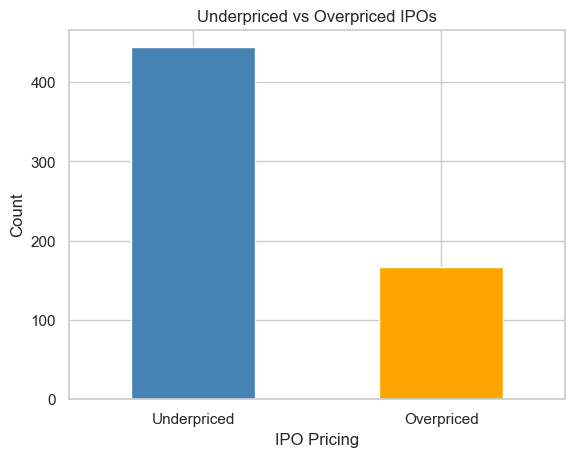

In [16]:
df["IPO_Pricing"].value_counts().plot(kind="bar", color=["steelblue","orange"])
plt.title("Underpriced vs Overpriced IPOs")
plt.xlabel("IPO Pricing")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


#### target is imbalanced — more Underpriced than Overpriced IPOs

## EDA

#### 1. Underpriced vs Overpriced count

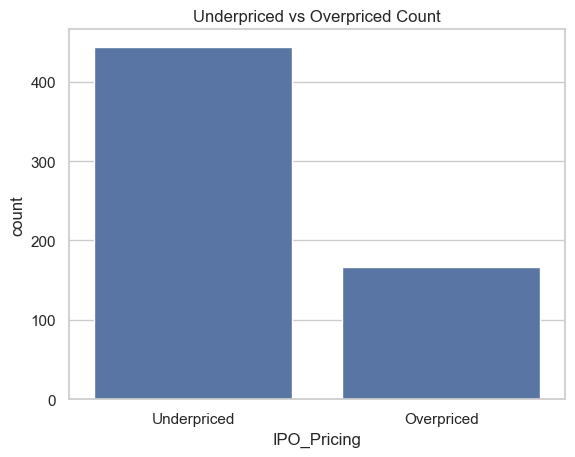

In [17]:
sns.countplot(data=df, x="IPO_Pricing")
plt.title("Underpriced vs Overpriced Count")
plt.show()


#### 2. Offer Price distribution

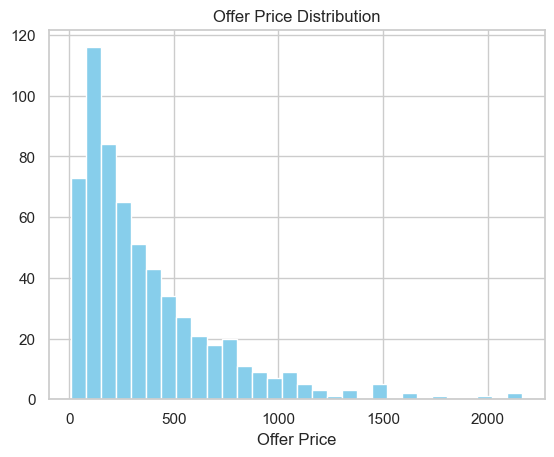

In [18]:
plt.hist(df["Offer Price"], bins=30, color="skyblue")
plt.title("Offer Price Distribution")
plt.xlabel("Offer Price")
plt.show()


#### 3. Issue Size distribution

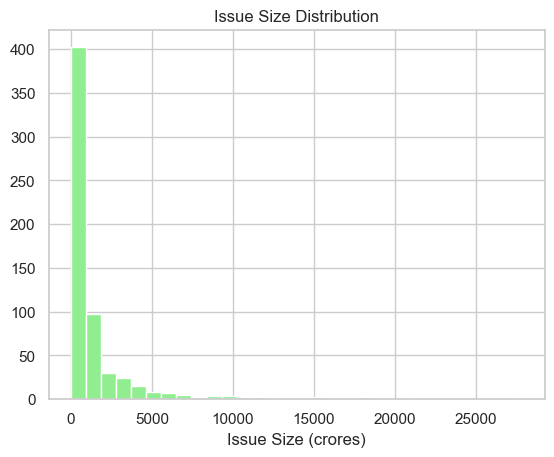

In [19]:
plt.hist(df["Issue_Size(crores)"], bins=30, color="lightgreen")
plt.title("Issue Size Distribution")
plt.xlabel("Issue Size (crores)")
plt.show()


#### 4. Offer Price by IPO Pricing

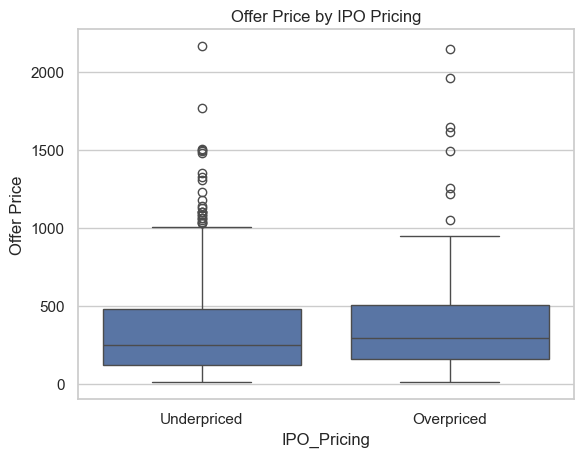

In [20]:
sns.boxplot(data=df, x="IPO_Pricing", y="Offer Price")
plt.title("Offer Price by IPO Pricing")
plt.show()


#### 5. Issue Size by IPO Pricing

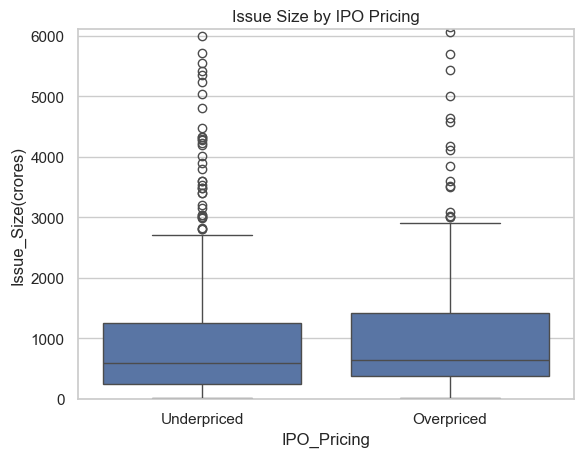

In [21]:
sns.boxplot(data=df, x="IPO_Pricing", y="Issue_Size(crores)")
plt.title("Issue Size by IPO Pricing")
plt.ylim(0, df["Issue_Size(crores)"].quantile(0.95))
plt.show()


#### 6. Average QIB subscription by IPO Pricing

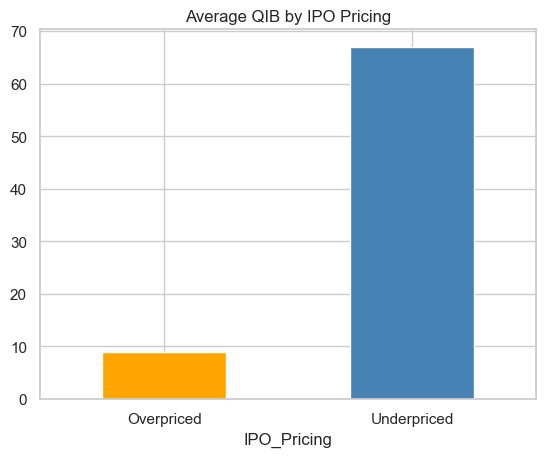

In [22]:
df.groupby("IPO_Pricing")["QIB"].mean().plot(kind="bar", color=["orange","steelblue"])
plt.title("Average QIB by IPO Pricing")
plt.xticks(rotation=0)
plt.show()


#### 7. Average HNI subscription by IPO Pricing

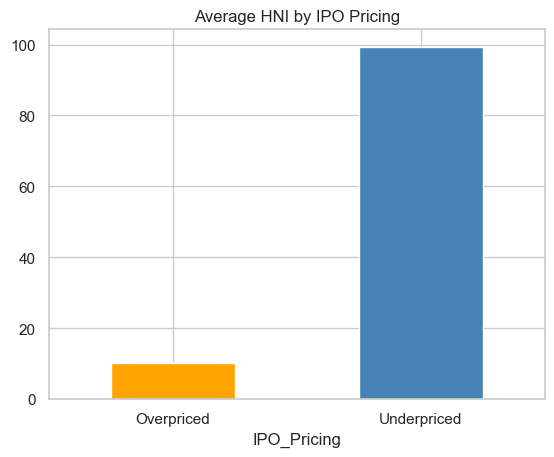

In [23]:
df.groupby("IPO_Pricing")["HNI"].mean().plot(kind="bar", color=["orange","steelblue"])
plt.title("Average HNI by IPO Pricing")
plt.xticks(rotation=0)
plt.show()


#### 8. Average RII subscription by IPO Pricing

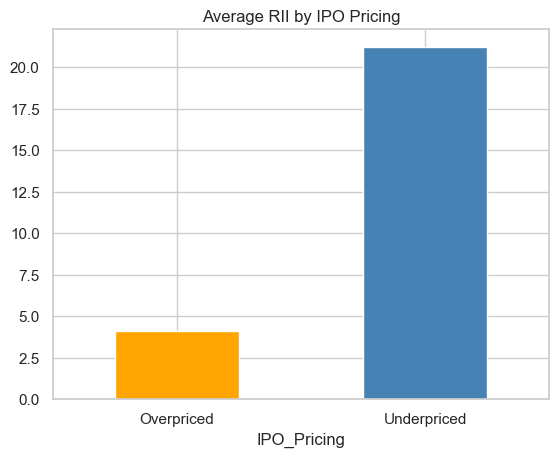

In [24]:
df.groupby("IPO_Pricing")["RII"].mean().plot(kind="bar", color=["orange","steelblue"])
plt.title("Average RII by IPO Pricing")
plt.xticks(rotation=0)
plt.show()


#### 9. Average Total subscription by IPO Pricing

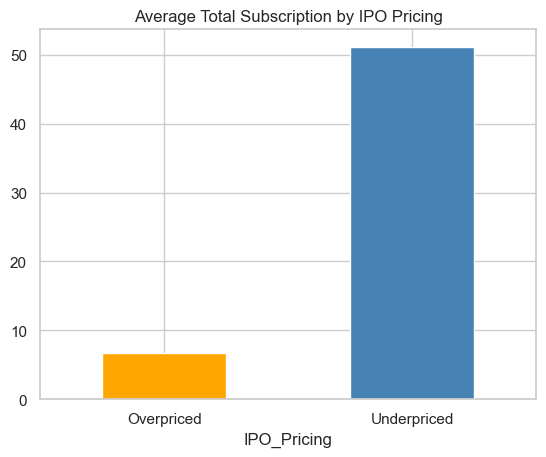

In [25]:
df.groupby("IPO_Pricing")["Total"].mean().plot(kind="bar", color=["orange","steelblue"])
plt.title("Average Total Subscription by IPO Pricing")
plt.xticks(rotation=0)
plt.show()


#### 10. Correlation heatmap

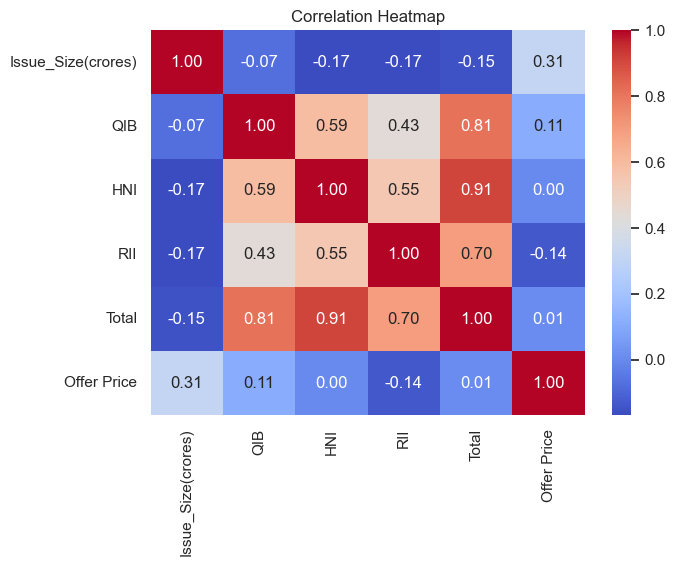

In [26]:
plt.figure(figsize=(7,5))
sns.heatmap(df.drop(columns="IPO_Pricing").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### Insights
- Underpriced IPOs are more common than Overpriced ones (imbalanced target)
- Offer Price and Issue Size are both right-skewed — a few large IPOs pull the range up
- QIB, HNI and RII subscriptions are on average higher for Underpriced IPOs
- Total subscription is highly correlated with QIB/HNI/RII since it's built from them
- No single feature clearly separates the two classes on its own

## Prepare X and y

In [27]:
X = df.drop("IPO_Pricing", axis=1)
y = df["IPO_Pricing"]


#### encode target (Overpriced=0, Underpriced=1)

In [28]:
le = LabelEncoder()
y = le.fit_transform(y)

print(list(le.classes_))
y[:10]


['Overpriced', 'Underpriced']


array([1, 1, 1, 1, 1, 0, 0, 0, 1, 1])

## Train-test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((488, 6), (123, 6))

## Feature scaling

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Build baseline SVM model

In [31]:
svm_model = SVC(kernel="linear", random_state=42)

svm_model.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
y_pred = svm_model.predict(X_test_scaled)


## Evaluate baseline SVM

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.7317073170731707
Precision: 0.7295081967213115
Recall   : 1.0
F1 Score : 0.8436018957345972


In [34]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.03      0.06        34
           1       0.73      1.00      0.84        89

    accuracy                           0.73       123
   macro avg       0.86      0.51      0.45       123
weighted avg       0.80      0.73      0.63       123



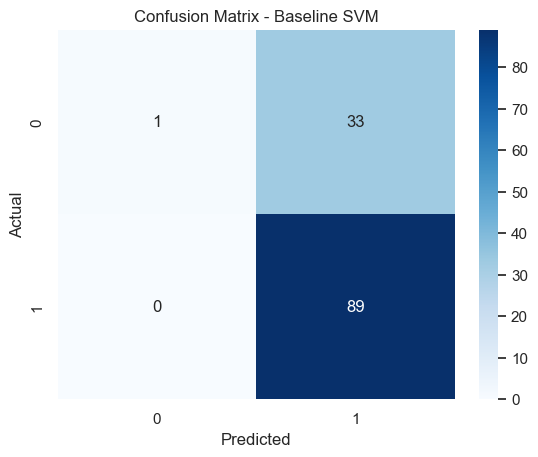

In [35]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Compare SVM kernels

In [36]:
results = []

for k in ["linear","rbf","poly"]:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    results.append({
        "Model": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

kernel_df = pd.DataFrame(results)
kernel_df


,Model,Accuracy,Precision,Recall,F1 Score
0,linear,0.731707,0.729508,1.000000,0.843602
1,rbf,0.707317,0.719008,0.977528,0.828571
2,poly,0.723577,0.727273,0.988764,0.838095


## Hyperparameter tuning using GridSearchCV

In [37]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train)


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [38]:
grid_search.best_params_


{'C': 10, 'gamma': 'auto', 'kernel': 'poly'}

In [39]:
grid_search.best_score_


np.float64(0.7358089627603619)

## Final model

In [40]:
best_svm = grid_search.best_estimator_

final_pred = best_svm.predict(X_test_scaled)


In [41]:
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))


Accuracy : 0.6747967479674797
Precision: 0.7247706422018348
Recall   : 0.8876404494382022
F1 Score : 0.797979797979798


In [42]:
print(classification_report(y_test, final_pred))


              precision    recall  f1-score   support

           0       0.29      0.12      0.17        34
           1       0.72      0.89      0.80        89

    accuracy                           0.67       123
   macro avg       0.51      0.50      0.48       123
weighted avg       0.60      0.67      0.62       123



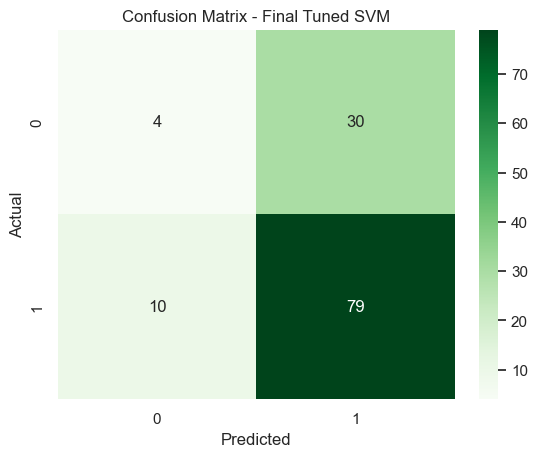

In [43]:
cm2 = confusion_matrix(y_test, final_pred)

sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Final Tuned SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Final model comparison

In [44]:
final_row = pd.DataFrame([{
    "Model": "Tuned SVM",
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred),
    "Recall": recall_score(y_test, final_pred),
    "F1 Score": f1_score(y_test, final_pred)
}])

comparison = pd.concat([kernel_df, final_row], ignore_index=True)
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,linear,0.731707,0.729508,1.000000,0.843602
1,rbf,0.707317,0.719008,0.977528,0.828571
2,poly,0.723577,0.727273,0.988764,0.838095
3,Tuned SVM,0.674797,0.724771,0.887640,0.797980


#### best model = the row with highest F1 Score above (Underpriced class is majority so accuracy alone is misleading)

## Conclusion

- We predicted whether an IPO is Underpriced or Overpriced using SVM
- Features used: Issue Size, QIB, HNI, RII, Total subscription, Offer Price
- Best model was the Tuned SVM from GridSearchCV (see comparison table above)
- Final accuracy is shown in the comparison table
- Takeaway: strong subscription demand (QIB/HNI/RII) tends to line up with Underpriced IPOs, but the model still struggles with the minority Overpriced class due to imbalance